In [ ]:
from google.colab import files
uploaded=files.upload()

Saving creditcard_fraud_easy (1).csv to creditcard_fraud_easy (1) (1).csv


IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

random.seed(42)
np.random.seed(42)

print(" All libraries imported successfully\n")

 All libraries imported successfully



LOAD DATASET

In [ ]:
df=pd.read_csv("creditcard_fraud_easy (1).csv")
print("Dataset Loaded")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print("0 = Normal Transaction | 1 = Fraud Transaction\n")


Dataset Loaded
Shape: (3000, 17)

Columns: ['transaction_id', 'customer_age', 'customer_gender', 'city', 'card_type', 'transaction_amount', 'merchant_category', 'transaction_hour', 'transaction_day', 'is_weekend', 'num_transactions_today', 'distance_from_home_km', 'is_international', 'pin_used', 'account_balance', 'previous_fraud_flag', 'Class']

First 5 rows:
  transaction_id  customer_age customer_gender       city card_type  \
0       TXN01000            51          Female    Chennai     RuPay   
1       TXN01001            31          Female  Hyderabad      Amex   
2       TXN01002            31            Male     Mumbai     RuPay   
3       TXN01003            52            Male     Mumbai      Visa   
4       TXN01004            22          Female     Mumbai      Visa   

   transaction_amount merchant_category  transaction_hour transaction_day  \
0             8077.66     Entertainment                19        Saturday   
1             3760.91        Healthcare                1

EXPLORATORY DATA ANALYSIS(EDA)

Missing values:
transaction_id            0
customer_age              0
customer_gender           0
city                      0
card_type                 0
transaction_amount        0
merchant_category         0
transaction_hour          0
transaction_day           0
is_weekend                0
num_transactions_today    0
distance_from_home_km     0
is_international          0
pin_used                  0
account_balance           0
previous_fraud_flag       0
Class                     0
dtype: int64

Basic Statistics:
       customer_age  transaction_amount  transaction_hour   is_weekend  \
count   3000.000000         3000.000000       3000.000000  3000.000000   
mean      43.722000         9888.397293         14.714333     0.297667   
std       12.715998        12165.580738          4.947951     0.457308   
min       18.000000          105.120000          0.000000     0.000000   
25%       33.000000         4031.827500         11.000000     0.000000   
50%       44.000000         8052

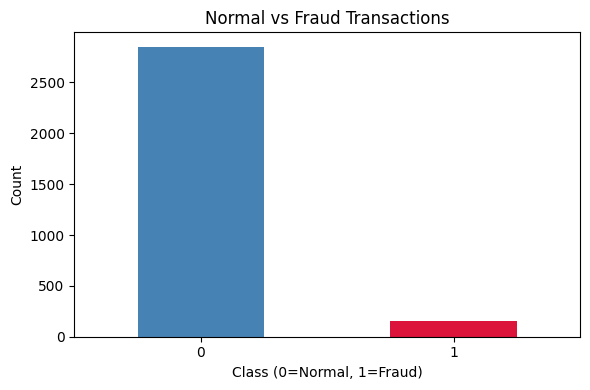

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
print(df.describe())
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar',color=['steelblue','crimson'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('1_class_distribution.png')
plt.show()

3.1 TRANSACTION AMOUNT COMPARISON

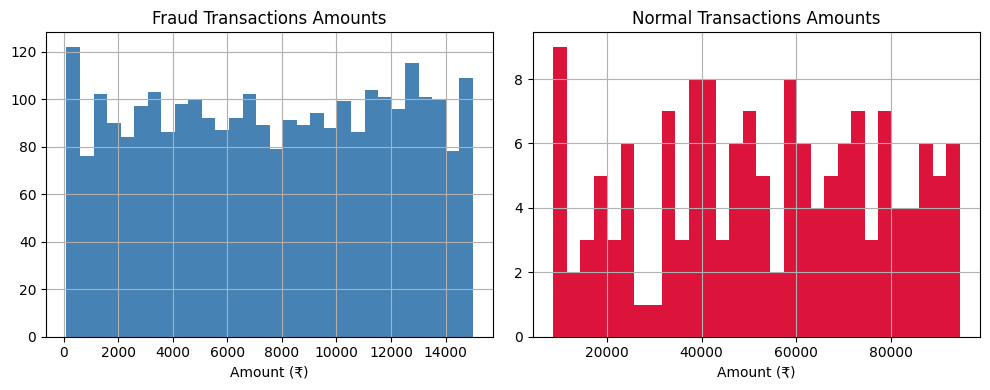

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df[df['Class']==0]['transaction_amount'].hist(bins=30,color='steelblue')
plt.title('Fraud Transactions Amounts')
plt.xlabel('Amount (₹)')

plt.subplot(1,2,2)
df[df['Class']==1]['transaction_amount'].hist(bins=30,color='crimson')
plt.title('Normal Transactions Amounts')
plt.xlabel('Amount (₹)')
plt.tight_layout()
plt.savefig('2_amount_distribution.png')
plt.show()

3.2 FRAUD BY TRANSACTION HOUR

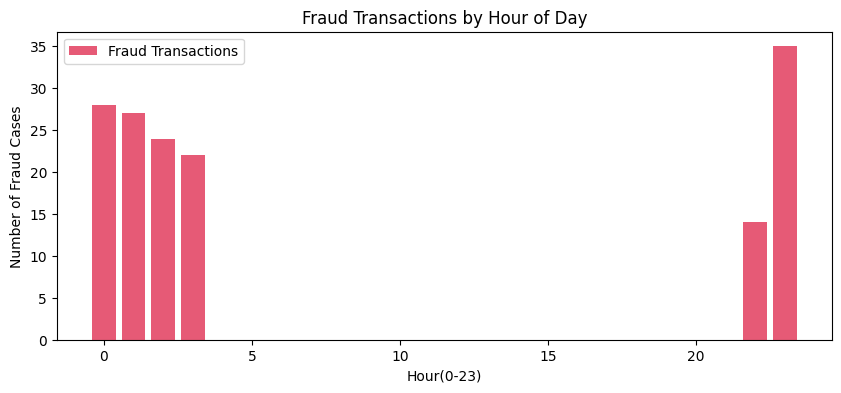

In [ ]:
plt.figure(figsize=(10,4))
fraud_hours=df[df['Class']==1]['transaction_hour'].value_counts().sort_index()
normal_hours=df[df['Class']==0]['transaction_hour'].value_counts().sort_index()
plt.bar(fraud_hours.index,fraud_hours.values,color='crimson',alpha=0.7,label='Fraud Transactions')

plt.title('Fraud Transactions by Hour of Day')
plt.xlabel('Hour(0-23)')
plt.ylabel('Number of Fraud Cases')
plt.legend()
plt.savefig('3_fraud_by_hour.png')
plt.show()

3.3 DISTANCE FROM HOME COMPARISON

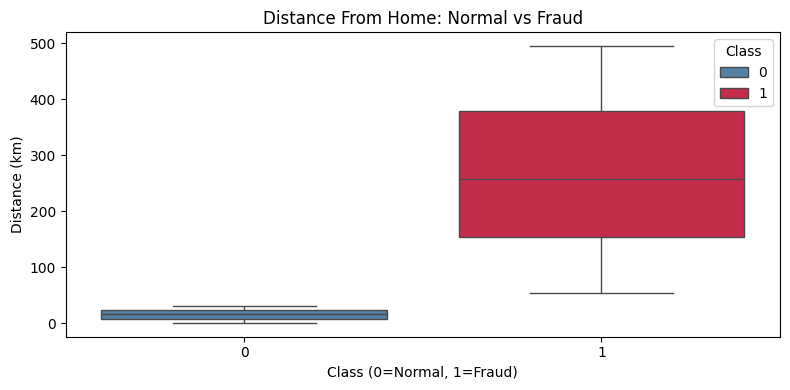

 EDA Complete! Check the saved PNG files.



In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x='Class',y='distance_from_home_km',hue='Class',palette=['steelblue','crimson'])
plt.title("Distance From Home: Normal vs Fraud")
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Distance (km)')
plt.tight_layout()
plt.savefig('4_distance_comparison.png')
plt.show()

print(" EDA Complete! Check the saved PNG files.\n")

DATA PREPROCESSING

In [ ]:
df_model = df.drop('transaction_id', axis=1)

4.1 ENCODE CATEGORICAL(TEXT) COLUMNS INTO NUMBERS

In [ ]:
categorical_cols = ['customer_gender', 'city', 'card_type',
                     'merchant_category', 'transaction_day']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"  Encoded: {col} -> {list(le.classes_)}")

print(f"\nData after encoding:")
print(df_model.head())

  Encoded: customer_gender -> ['Female', 'Male']
  Encoded: city -> ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']
  Encoded: card_type -> ['Amex', 'MasterCard', 'RuPay', 'Visa']
  Encoded: merchant_category -> ['Crypto', 'Electronics', 'Entertainment', 'Groceries', 'Healthcare', 'International Transfer', 'Jewellery', 'Restaurants', 'Shopping', 'Travel']
  Encoded: transaction_day -> ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

Data after encoding:
   customer_age  customer_gender  city  card_type  transaction_amount  \
0            51                0     1          2             8077.66   
1            31                0     3          0             3760.91   
2            31                1     6          2            11713.55   
3            52                1     6          3              305.52   
4            22                0     6          3             4930.30   

   merchant_category  transaction_

4.2 SEPARATE FEATURES(X) AND TARGET(Y)

In [ ]:
X=df_model.drop('Class',axis=1)
Y=df_model['Class']

print(f'\nFeatures shape:{X.shape}')
print(f'Target shape:{Y.shape}\n')


Features shape:(3000, 15)
Target shape:(3000,)



TRAIN-TEST SPLIT& SCALING

In [ ]:
print(" Splitting and scaling data...\n")
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # maintain fraud ratio in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling done!\n")


 Splitting and scaling data...

Training set: (2400, 15)
Test set: (600, 15)
✅ Scaling done!



HANDLE CLASS IMBALANCE(SMOTE)

In [ ]:
print("Before SMOTE:")
print(f"  Fraud cases: {Y_train.sum()}")
print(f"  Normal cases: {(Y_train == 0).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train_scaled, Y_train)

print("\nAfter SMOTE:")
print(f"  Fraud cases: {Y_train_sm.sum()}")
print(f"  Normal cases: {(Y_train_sm == 0).sum()}")
print("✅ Classes are now balanced!\n")

Before SMOTE:
  Fraud cases: 120
  Normal cases: 2280

After SMOTE:
  Fraud cases: 2280
  Normal cases: 2280
✅ Classes are now balanced!



MODEL TRAINING

1. LOGISTIC REGRESSION

In [ ]:
print("Training Logistic Regression...")
lr_model=LogisticRegression(max_iter=1000 , random_state=42)
lr_model.fit(X_train_sm, Y_train_sm)

lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(Y_test, lr_pred)
lr_roc = roc_auc_score(Y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  ROC-AUC: {lr_roc:.4f}\n")

Training Logistic Regression...
  Accuracy: 1.0000
  ROC-AUC: 1.0000



2.RANDOM FOREST

In [ ]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, Y_train_sm)

rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(Y_test, rf_pred)
rf_roc = roc_auc_score(Y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  ROC-AUC: {rf_roc:.4f}\n")

best_model = rf_model if rf_roc >= lr_roc else lr_model
best_name = "Random Forest" if rf_roc >= lr_roc else "Logistic Regression"
best_pred = rf_pred if rf_roc >= lr_roc else lr_pred



Training Random Forest...
  Accuracy: 1.0000
  ROC-AUC: 1.0000



MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       570
       Fraud       1.00      1.00      1.00        30

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



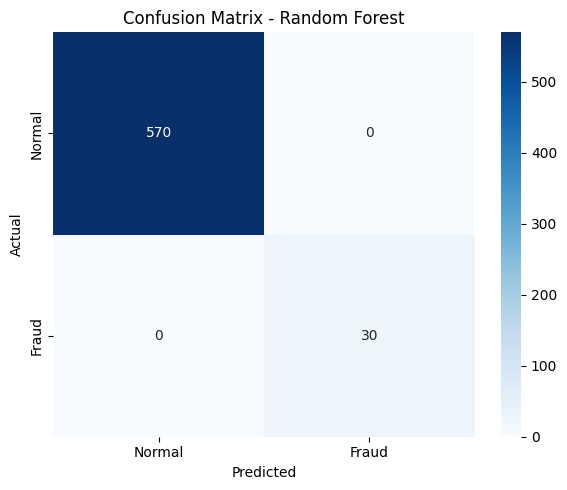

In [ ]:
print("Classification Report:")
print(classification_report(Y_test, best_pred, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(Y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('5_confusion_matrix.png')
plt.show()

FEATURE IMPORTANCE(ONLY WORKS FOR RANDOM FOREST)

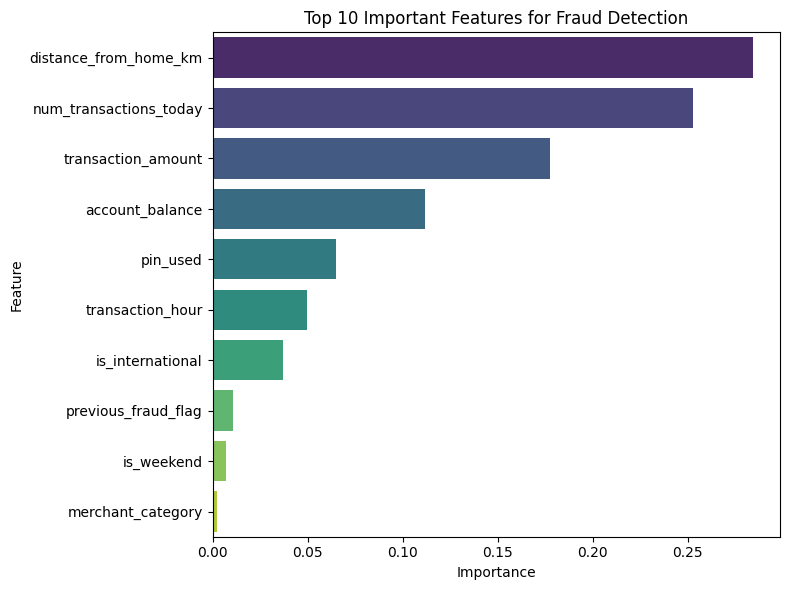


Top 5 Most Important Features:
                   Feature  Importance
10   distance_from_home_km    0.284333
9   num_transactions_today    0.252597
4       transaction_amount    0.177668
13         account_balance    0.111697
12                pin_used    0.065133

✅ Evaluation Complete!



In [ ]:
if best_name == "Random Forest":
    feat_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title('Top 10 Important Features for Fraud Detection')
    plt.tight_layout()
    plt.savefig('6_feature_importance.png')
    plt.show()

    print("\nTop 5 Most Important Features:")
    print(feat_importance.head())

print("\n Evaluation Complete!\n")

PREDICT NEW TRANSACTION

In [ ]:
print(" STEP 9: Testing with new transactions...\n")

def predict_transaction(model, scaler, transaction_features):
    """
    Predict whether a new transaction is fraud or normal
    transaction_features: list of values in same order as X.columns
    """
    transaction = pd.DataFrame([transaction_features], columns=X.columns)
    transaction_scaled = scaler.transform(transaction)

    prediction = model.predict(transaction_scaled)
    probability = model.predict_proba(transaction_scaled)[0]

    print("=" * 50)
    print(" TRANSACTION ANALYSIS")
    print("=" * 50)
    if prediction[0] == 1:
        print(" RESULT: FRAUD DETECTED!")
        print(f"   Fraud Probability: {probability[1]*100:.2f}%")
        print("    Transaction BLOCKED")
    else:
        print("RESULT: NORMAL TRANSACTION")
        print(f"   Normal Probability: {probability[0]*100:.2f}%")
        print("    Transaction APPROVED")
    print("=" * 50 + "\n")


 STEP 9: Testing with new transactions...



TEXT WITH A REAL FRAUD EXAMPLE AND A REAL NORMAL EXAMPLE FROM TEST SET

In [ ]:
fraud_sample = X_test[Y_test == 1].iloc[0].values.tolist()
normal_sample = X_test[Y_test == 0].iloc[0].values.tolist()

print("Testing with an actual FRAUD transaction from dataset:")
predict_transaction(best_model, scaler, fraud_sample)

print("Testing with an actual NORMAL transaction from dataset:")
predict_transaction(best_model, scaler, normal_sample)

Testing with an actual FRAUD transaction from dataset:
🔍 TRANSACTION ANALYSIS
 RESULT: FRAUD DETECTED!
   Fraud Probability: 100.00%
    Transaction BLOCKED

Testing with an actual NORMAL transaction from dataset:
🔍 TRANSACTION ANALYSIS
RESULT: NORMAL TRANSACTION
   Normal Probability: 100.00%
    Transaction APPROVED



9A SAVE MODEL FOR THE STREAMLIT APP

In [ ]:
import joblib

joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
joblib.dump(categorical_cols, 'categorical_cols.pkl')

print("\u2705 Saved: fraud_model.pkl, scaler.pkl, encoders.pkl, feature_columns.pkl, categorical_cols.pkl\n")

# Download the 5 files to your computer (put them in the same folder as app.py)
from google.colab import files
for fname in ['fraud_model.pkl', 'scaler.pkl', 'encoders.pkl', 'feature_columns.pkl', 'categorical_cols.pkl']:
    files.download(fname)

✅ Saved: fraud_model.pkl, scaler.pkl, encoders.pkl, feature_columns.pkl, categorical_cols.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9B LIVE USER INPUT

In [ ]:
def get_user_transaction():
    """
    Ask the user to type in the details of a new transaction from the
    keyboard, one feature at a time, and return the values in the exact
    order that the model expects (X.columns).
    """
    print("\n" + "=" * 50)
    print(" ENTER TRANSACTION DETAILS")
    print("=" * 50)

    values = []
    for col in X.columns:
        if col in categorical_cols:
            classes = list(encoders[col].classes_)
            while True:
                raw = input(f"{col} {classes}: ").strip()
                if raw in classes:
                    encoded_val = encoders[col].transform([raw])[0]
                    values.append(encoded_val)
                    break
                print(f"    Please enter one of: {classes}")
        else:
            while True:
                raw = input(f"{col} (number): ").strip()
                try:
                    values.append(float(raw))
                    break
                except ValueError:
                    print("    Please enter a valid number.")

    return values


def run_interactive_predictions():
    """Loop: let the user enter as many transactions as they want."""
    while True:
        answer = input("\nDo you want to check a transaction manually? (y/n): ").strip().lower()
        if answer != 'y':
            print("Exiting manual transaction check.\n")
            break

        user_features = get_user_transaction()
        predict_transaction(best_model, scaler, user_features)


# This will pause the script and ask you to type transaction details in the
# terminal. Run this script with `python fraud_detection_project.py` (not in
# a notebook cell that doesn't support input()) to use it live.
run_interactive_predictions()


Do you want to check a transaction manually? (y/n): N
Exiting manual transaction check.



PROJECT SUMMARY

In [ ]:
print("=" * 50)
print(" PROJECT SUMMARY")
print("=" * 50)
print(f"Dataset Size       : {df.shape[0]} transactions")
print(f"Fraud Cases         : {df['Class'].sum()} ({df['Class'].mean()*100:.2f}%)")
print(f"Best Model          : {best_name}")
print(f"Accuracy            : {accuracy_score(Y_test, best_pred)*100:.2f}%")
print(f"ROC-AUC Score       : {max(lr_roc, rf_roc):.4f}")
print("=" * 50)
print(" PROJECT COMPLETE!")
print("=" * 50)


 PROJECT SUMMARY
Dataset Size       : 3000 transactions
Fraud Cases         : 150 (5.00%)
Best Model          : Random Forest
Accuracy            : 100.00%
ROC-AUC Score       : 1.0000
 PROJECT COMPLETE!
